# LowResPT · Reconstruction Attention Maps

**What is the model actually looking at?** — without using the CLS token.

In MAE pre-training the loss is computed **only on the patch-token reconstructions**;
the CLS token never receives a direct training signal, and the *all-visible* forward
pass is an off-distribution regime. So CLS-to-patch attention (the DINO-style readout)
is **not** a trustworthy saliency map here.

Instead we read attention in the regime the model was actually trained in. For a
**target token `t`** we mask a leak-free `BLOCK_K`-token block centred on it (exactly
the `reconstruct(masked=True)` protocol), run one forward pass, and read the
**last-layer attention from token `t`'s query to every other patch token**: this is the
set of spectral regions the model *consults to reconstruct that wavelength*. Sweeping
`t` over the sequence yields an `N×N` wavelength×wavelength attention matrix, entirely
from patch tokens.

**Derived views**
1. **Global saliency** — average source attention over all targets (masked block
   columns excluded): how much each spectral region is consulted overall.
2. **Per-line receptive field** — mask an emission-line token, see where the model
   looks to fill it in.
3. **Attention matrix** — the full wavelength×wavelength heatmap.
4. **Line vs continuum** — do line tokens attract more attention than continuum?


## 1 · Configuration & Imports

In [1]:
import sys, math
import numpy as np
import torch
import matplotlib.pyplot as plt
sys.path.insert(0, '.')

from model.low_res_pt import LowResPT
from data.datamodule import LowResDataModule

CKPT   = "/home/yacheng/ssl_outthere/encoder_spectrum/LowResPT/outputs/low_res_pt_1_2_micron/version_0/checkpoints/epoch=epoch=387-val_hid_loss=val_hid_loss=0.1063.ckpt"
FITS   = "/home/yacheng/ssl_outthere/data/spectrum/DJA_spectra_v4.5.fits"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

USE_JANSKY       = False   # must match training flux units
VAL_SN_THRESHOLD = 5       # high-S/N val spectra -> cleaner, line-rich examples

# Consecutive tokens masked around each target (mirror recon.ipynb).
# S == P (no overlap) -> 1 is leak-free; S < P -> use 2 or 3.
BLOCK_K = 1
print(f"Device: {DEVICE}")

Device: cuda


## 2 · Model & Data

In [2]:
from torch.utils.data import Subset

model = LowResPT.load_from_checkpoint(CKPT, map_location=DEVICE).eval()
wl_min = model.hparams['wl_ref_min']
wl_max = model.hparams['wl_ref_max']
N_HEADS = model.blocks[-1].attn.num_heads
print(f"model wavelength range: {wl_min}-{wl_max} um   n_heads={N_HEADS}   layers={model.num_layers}")

dm = LowResDataModule(fits_path=FITS, batch_size=256, num_workers=0,
                      min_sn50=1.0, min_redshift=0.0, use_jansky=USE_JANSKY,
                      wl_ref_min=wl_min, wl_ref_max=wl_max, frac_valid_pix=0.5)
dm.setup()

# Sub-select the val split to high-S/N spectra (does not perturb the partition).
base      = dm.val_dataset.dataset
val_local = np.asarray(dm.val_dataset.indices)
keep      = [int(i) for i in val_local if base.sn50[int(i)] >= VAL_SN_THRESHOLD]
dm.val_dataset = Subset(base, keep)
print(f"val split: {len(val_local)} -> {len(keep)} with sn50 >= {VAL_SN_THRESHOLD}")

batch = next(iter(dm.val_dataloader()))
print(f"batch flux shape: {batch['flux'].shape}")

model wavelength range: 1.0-2.0 um   n_heads=4   layers=8
Converting flux from f_nu (uJy) to f_lambda (∝ f_nu / λ²) (use_jansky=True to disable this conversion)
grade in (1, 2, 3) filtering: 26486/42196 samples kept
sn50 >= 1.0 filtering: 19967/42196 samples kept
z_best > 0.0 filtering: 17373/42196 samples kept
valid_pix_frac > 0.5 filtering: 16685/42196 samples kept
LowResDataset: 16685 spectra, 56 pixels (1.004–1.991 µm)
val split: 1669 -> 732 with sn50 >= 5
batch flux shape: torch.Size([256, 56])


## 3 · Emission Lines

Observed-frame line position = rest wavelength × (1+z). Used to (a) annotate plots and
(b) flag which tokens contain a line.

In [3]:
# Rest-frame vacuum wavelengths (micron) of the strongest optical/NIR lines.
LINES = {
    r'Ly$\alpha$': 0.12157,
    '[OII]':       0.37273,
    r'H$\beta$':   0.48613,
    '[OIII]':      0.50069,
    r'H$\alpha$':  0.65646,
    '[SII]':       0.67166,
    r'Pa$\beta$':  1.28216,
    'HeI':         1.08332,
}

def lines_obs(z, lo, hi):
    """Observed-frame line positions falling inside [lo, hi] for redshift z."""
    out = {}
    for name, rest in LINES.items():
        w = rest * (1 + float(z))
        if lo <= w <= hi:
            out[name] = w
    return out

## 4 · Attention Extraction (MAE-consistent)

`AttnCapture` re-derives the softmax attention from the last block's QKV, applying the
**same `key_padding_mask`** the model uses (invalid tokens excluded) so the weights match
the real forward pass. `attention_matrix` runs the leave-block-out reconstruction loop and
records, for each masked target `t`, that token's query attention over all patch tokens.

In [4]:
class AttnCapture:
    """Forward hook: softmax attention of a SelfAttention module, padding-mask aware."""
    def __init__(self):
        self.w = None      # (B, n_heads, T, T)
        self.kpm = None    # (B, T) bool, True = masked key

    def __call__(self, module, inp, out):
        x = inp[0]
        B, T, D = x.shape
        nh, hd = module.num_heads, module.head_dim
        with torch.no_grad():
            qkv = module.qkv(x).reshape(B, T, 3, nh, hd).permute(2, 0, 3, 1, 4)
            q, k = qkv[0], qkv[1]
            scores = (q @ k.transpose(-2, -1)) * module.scale
            if self.kpm is not None:
                scores = scores.masked_fill(self.kpm.unsqueeze(1).unsqueeze(2), float('-inf'))
            attn = scores.softmax(dim=-1)
            self.w = attn.masked_fill(torch.isnan(attn), 0.0).cpu()


@torch.no_grad()
def attention_matrix(model, batch, block_k=1):
    """Leave-block-out attention for every target token.

    Returns dict with:
        A          (B, N, N) source attention per masked target, heads-averaged.
                   A[b, t] = where token t looks when its block is masked.
        A_ext      (B, N, N) copy with each row's masked-block columns set to nan
                   (only attention to OTHER, visible tokens).
        wave_token (B, N)    mean observed wavelength per token
        tvm        (B, N)    bool per-token validity
        flux_norm  (B, L)    normalised pixel flux
        wave       (B, L)    observed wavelength grid
        L_used, z
    """
    flux  = batch['flux'].to(DEVICE)
    wave  = batch['wavelength'].to(DEVICE)
    vmask = batch['valid_mask'].to(DEVICE)

    flux_norm, mean, std = model._normalize_flux(flux, vmask, model.hparams.min_std)
    stats = torch.cat([mean, std], dim=-1)
    patches, wave_token, valid_patches, tvm, L_used = model._patchify(flux_norm, wave, vmask)
    patch_stats = model._compute_patch_stats(patches, valid_patches)
    B, N, P = patches.shape

    kpm = torch.cat([torch.zeros(B, 1, dtype=torch.bool, device=DEVICE), ~tvm], dim=1)
    cap = AttnCapture(); cap.kpm = kpm
    h = model.blocks[-1].attn.register_forward_hook(cap)

    A = torch.full((B, N, N), float('nan'))
    half_lo, half_hi = (block_k - 1) // 2, block_k // 2
    for t in range(N):
        tlo, thi = max(0, t - half_lo), min(N - 1, t + half_hi)
        mp = patches.clone();     mp[:, tlo:thi + 1, :] = 0.0
        ps = patch_stats.clone(); ps[:, tlo:thi + 1, :] = 0.0
        model.forward(mp, wave_token, tvm, stats, patch_stats=ps)
        # row t+1 (skip CLS), sources = patch tokens (skip CLS col)
        A[:, t, :] = cap.w[:, :, t + 1, 1:].mean(dim=1)
    h.remove()

    # exclude self / masked-block source columns
    A_ext = A.clone()
    for t in range(N):
        tlo, thi = max(0, t - half_lo), min(N - 1, t + half_hi)
        A_ext[:, t, tlo:thi + 1] = float('nan')

    # invalid tokens carry no meaningful attention as source or target
    tvm_cpu = tvm.cpu()
    A[~tvm_cpu.unsqueeze(1).expand(-1, N, -1)]     = float('nan')
    A_ext[~tvm_cpu.unsqueeze(1).expand(-1, N, -1)] = float('nan')

    return dict(A=A, A_ext=A_ext, wave_token=wave_token.cpu(), tvm=tvm_cpu,
                flux_norm=flux_norm.cpu(), wave=wave.cpu(), L_used=L_used,
                z=batch['redshift'])

R = attention_matrix(model, batch, block_k=BLOCK_K)
print("A:", tuple(R['A'].shape), " tokens/spectrum:", R['A'].shape[1])

A: (256, 27, 27)  tokens/spectrum: 27


## 5 · Global Saliency

For each spectrum, average the source attention over all masked targets (excluding the
masked block itself). The result is a per-token score: **how often the model consults
each spectral region when reconstructing the rest of the spectrum.** Overlaid on the
normalised flux, with emission lines marked.

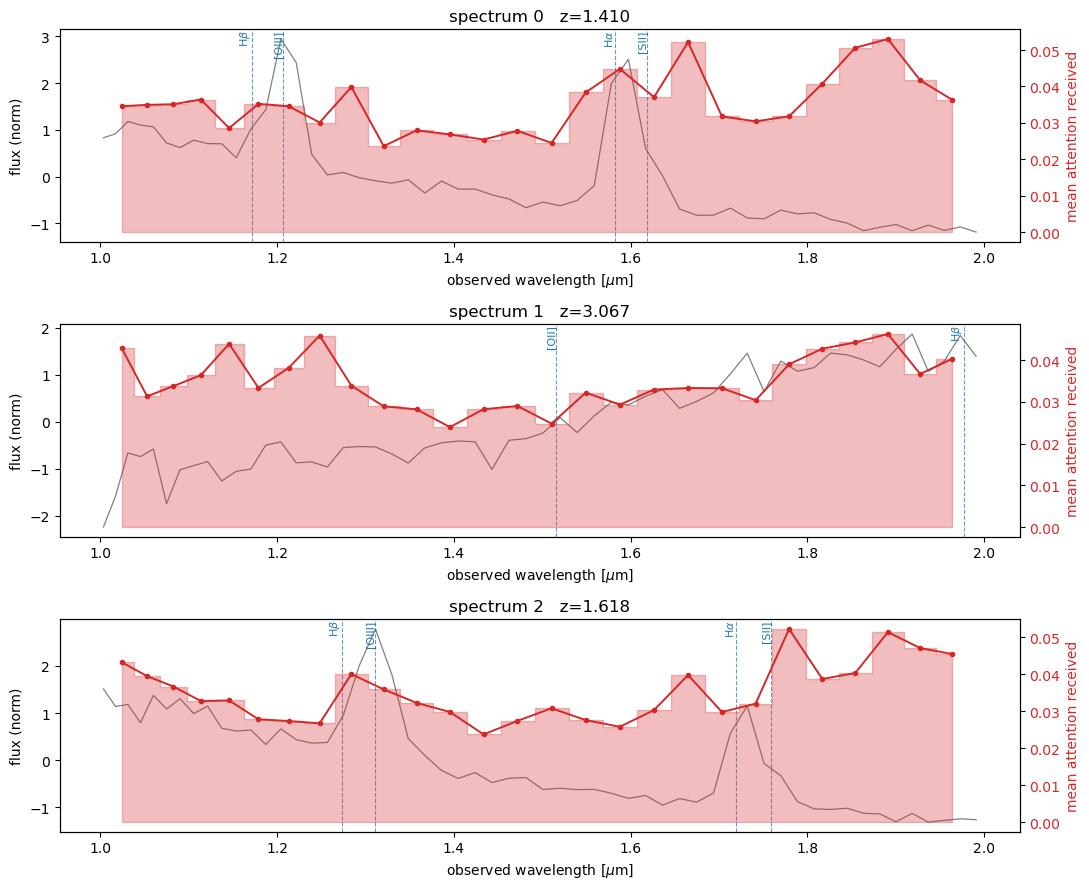

In [13]:
def plot_saliency(R, b, ax=None):
    wave_t = R['wave_token'][b].numpy()
    tvm    = R['tvm'][b].numpy()
    L      = R['L_used']
    wpix   = R['wave'][b, :L].numpy()
    fpix   = R['flux_norm'][b, :L].numpy()
    z      = float(R['z'][b])

    sal = np.nanmean(R['A_ext'][b].numpy(), axis=0)   # (N,) mean over targets
    sal = np.where(tvm, sal, np.nan)

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(wpix, fpix, color='0.5', lw=0.9, label='flux (norm)')
    ax2 = ax.twinx()
    m = np.isfinite(sal)
    ax2.fill_between(wave_t[m], 0, sal[m], color='tab:red', alpha=0.30, step='mid')
    ax2.plot(wave_t[m], sal[m], color='tab:red', lw=1.4, marker='.', label='saliency')
    ax2.set_ylabel('mean attention received', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    for name, w in lines_obs(z, wpix.min(), wpix.max()).items():
        ax.axvline(w, color='tab:blue', ls='--', lw=0.8, alpha=0.7)
        ax.text(w, ax.get_ylim()[1], name, rotation=90, va='top', ha='right',
                fontsize=8, color='tab:blue')
    ax.set_xlabel(r'observed wavelength [$\mu$m]')
    ax.set_ylabel('flux (norm)')
    ax.set_title(f'spectrum {b}   z={z:.3f}')
    return ax

# gallery of a few high-S/N spectra
sel = list(range(min(3, R['A'].shape[0])))
fig, axes = plt.subplots(len(sel), 1, figsize=(11, 3.0 * len(sel)))
axes = np.atleast_1d(axes)
for ax, b in zip(axes, sel):
    plot_saliency(R, b, ax)
plt.tight_layout(); plt.show()

## 6 · Per-Line Receptive Field

Pick the token whose observed-frame window contains a chosen emission line, mask it, and
plot **only that token's** attention over the spectrum: the regions the model pulls from
to reconstruct the line (neighbouring continuum? other lines?).

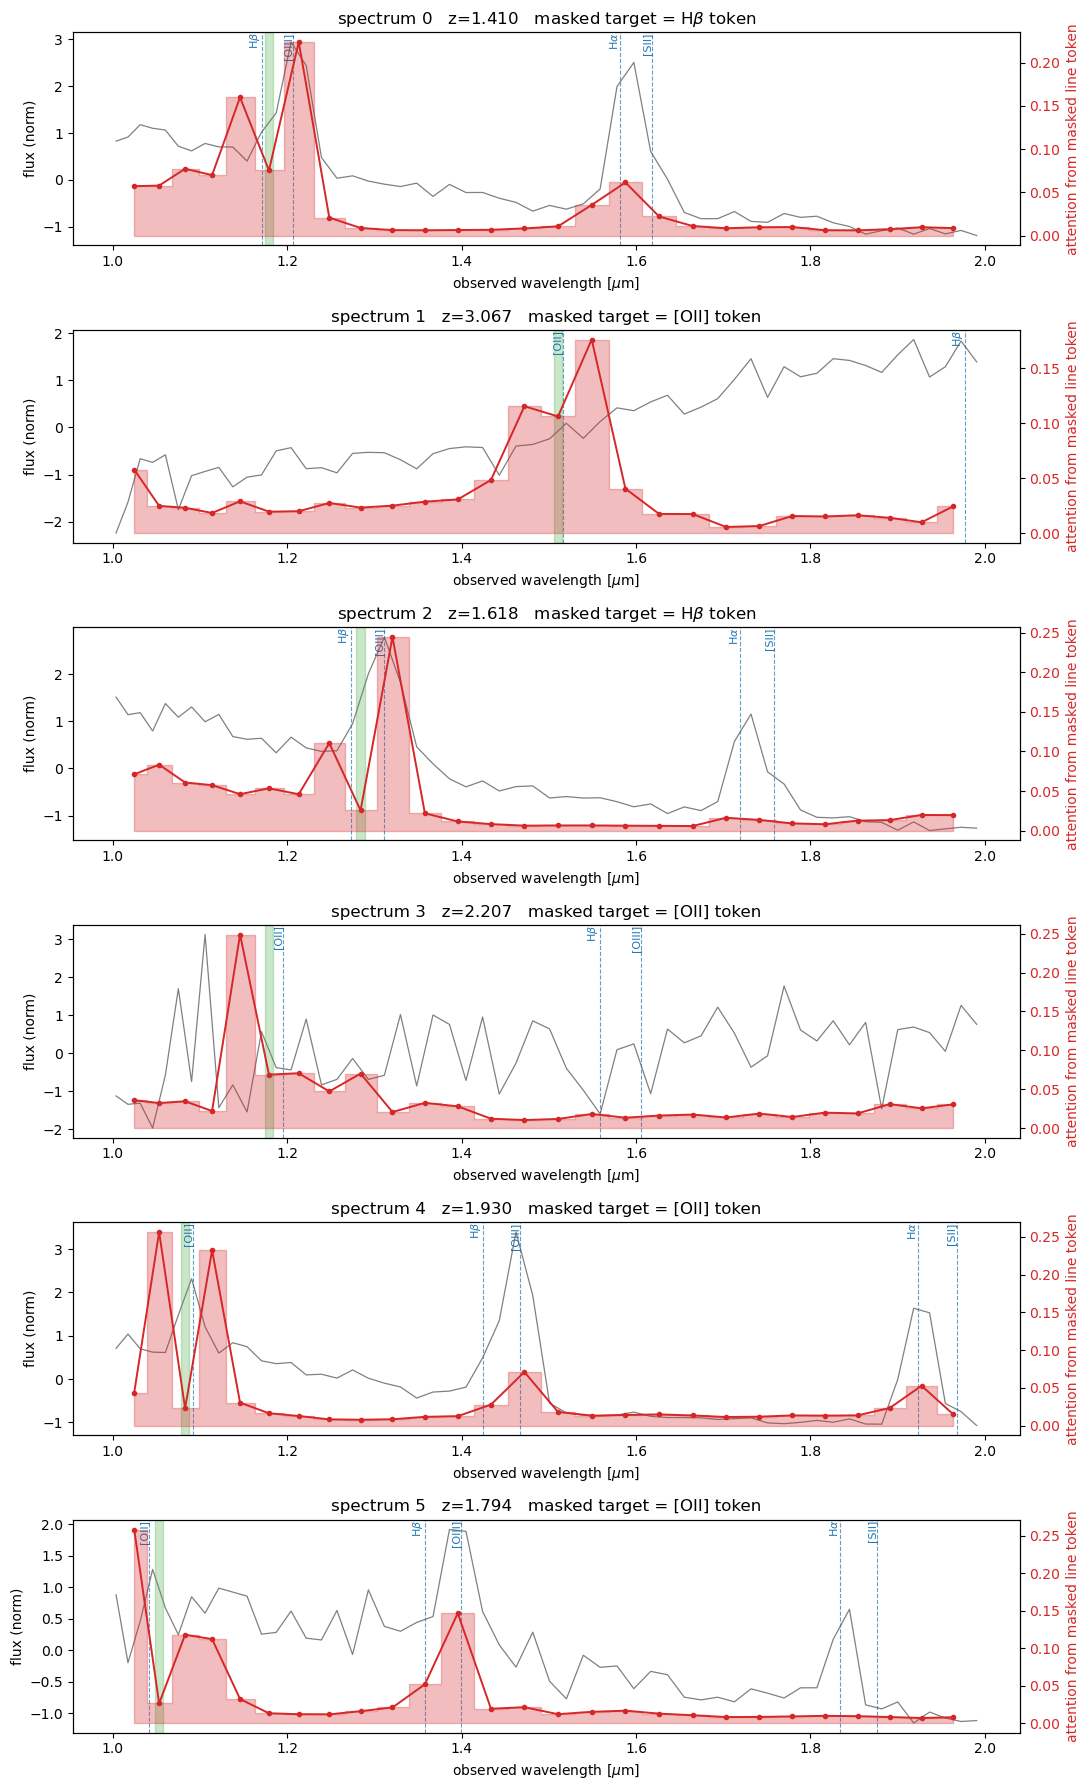

In [10]:
def token_of_wavelength(R, b, w_obs):
    """Index of the valid token whose mean wavelength is closest to w_obs."""
    wave_t = R['wave_token'][b].numpy().copy()
    wave_t[~R['tvm'][b].numpy()] = np.inf
    return int(np.argmin(np.abs(wave_t - w_obs)))

def plot_receptive_field(R, b, line_name=None, ax=None):
    wave_t = R['wave_token'][b].numpy()
    tvm    = R['tvm'][b].numpy()
    L      = R['L_used']
    wpix   = R['wave'][b, :L].numpy()
    fpix   = R['flux_norm'][b, :L].numpy()
    z      = float(R['z'][b])

    avail = lines_obs(z, wpix.min(), wpix.max())
    if not avail:
        print(f"spectrum {b}: no catalogued lines in range"); return
    if line_name is None or line_name not in avail:
        line_name = max(avail, key=lambda k: 0)   # first available
        line_name = list(avail.keys())[0]
    w_line = avail[line_name]
    t = token_of_wavelength(R, b, w_line)

    rf = R['A'][b, t].numpy()          # this target's attention over sources
    rf = np.where(tvm, rf, np.nan)

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(wpix, fpix, color='0.5', lw=0.9)
    ax.axvspan(wave_t[t] - 0.005, wave_t[t] + 0.005, color='tab:green', alpha=0.25)
    ax2 = ax.twinx()
    m = np.isfinite(rf)
    ax2.fill_between(wave_t[m], 0, rf[m], color='tab:red', alpha=0.30, step='mid')
    ax2.plot(wave_t[m], rf[m], color='tab:red', lw=1.4, marker='.')
    ax2.set_ylabel('attention from masked line token', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    for name, w in avail.items():
        ax.axvline(w, color='tab:blue', ls='--', lw=0.8, alpha=0.7)
        ax.text(w, ax.get_ylim()[1], name, rotation=90, va='top', ha='right',
                fontsize=8, color='tab:blue')
    ax.set_xlabel(r'observed wavelength [$\mu$m]')
    ax.set_ylabel('flux (norm)')
    ax.set_title(f'spectrum {b}   z={z:.3f}   masked target = {line_name} token')
    return ax

fig, axes = plt.subplots(len(sel), 1, figsize=(11, 3.0 * len(sel)))
axes = np.atleast_1d(axes)
for ax, b in zip(axes, sel):
    plot_receptive_field(R, b, ax=ax)
plt.tight_layout(); plt.show()

## 7 · Attention Matrix (wavelength × wavelength)

The full `N×N` matrix for one spectrum. Row = masked target wavelength, column = source
wavelength, colour = attention weight. Bright off-diagonal blocks reveal long-range
couplings (e.g. one line attending to another).

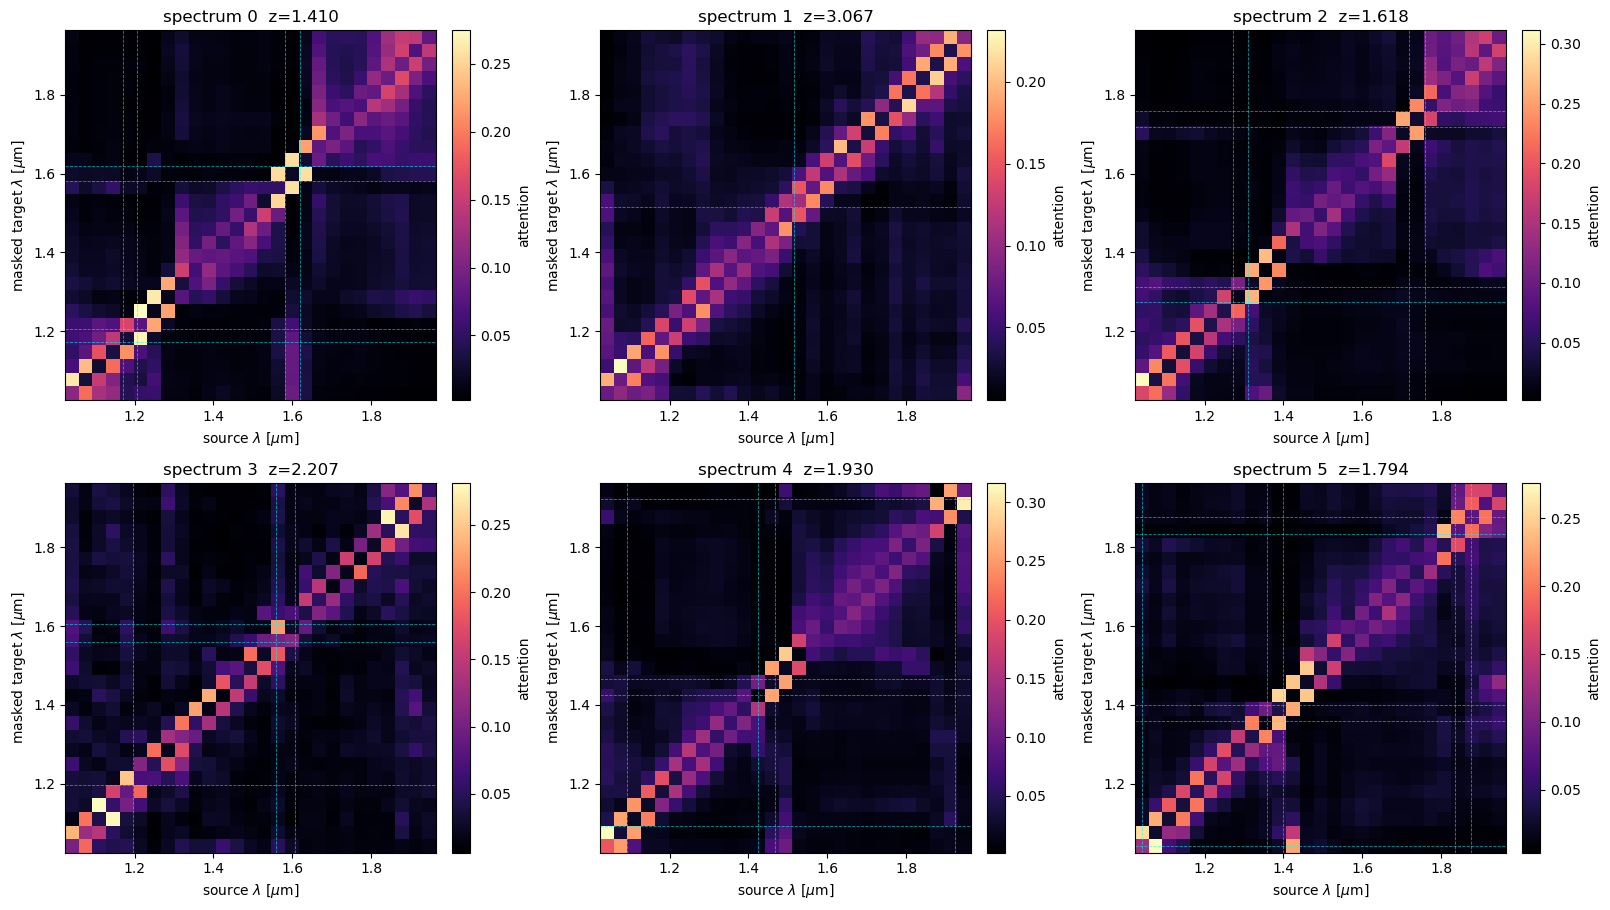

In [11]:
def plot_attn_matrix(R, b, ax=None):
    tvm    = R['tvm'][b].numpy()
    wave_t = R['wave_token'][b].numpy()
    A      = R['A'][b].numpy()
    idx    = np.where(tvm)[0]
    M      = A[np.ix_(idx, idx)]
    wt     = wave_t[idx]

    if ax is None:
        _, ax = plt.subplots(figsize=(5.4, 4.6))
    im = ax.imshow(M, origin='lower', cmap='magma', aspect='auto',
                   extent=[wt.min(), wt.max(), wt.min(), wt.max()])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='attention')
    z = float(R['z'][b])
    for _, w in lines_obs(z, wt.min(), wt.max()).items():
        ax.axvline(w, color='cyan', ls='--', lw=0.6, alpha=0.6)
        ax.axhline(w, color='cyan', ls='--', lw=0.6, alpha=0.6)
    ax.set_xlabel(r'source $\lambda$ [$\mu$m]')
    ax.set_ylabel(r'masked target $\lambda$ [$\mu$m]')
    ax.set_title(f'spectrum {b}  z={z:.3f}')
    return ax

ncol = 3
nrow = int(np.ceil(len(sel) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 4.6 * nrow))
for ax, b in zip(np.atleast_1d(axes).ravel(), sel):
    plot_attn_matrix(R, b, ax)
for ax in np.atleast_1d(axes).ravel()[len(sel):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 8 · Line vs Continuum — Population Summary

Across many spectra: classify each token by whether its observed-frame window contains a
catalogued line, then compare the **global saliency** (attention received) of line tokens
vs continuum tokens. If the model has learned spectral structure, line tokens should be
consulted more than continuum (ratio > 1).

/tmp/ipykernel_555418/3571658950.py:19: RuntimeWarning: Mean of empty slice
  sal = np.nanmean(Rb['A_ext'][b].numpy(), axis=0)


line tokens: 3467  mean=0.0364
cont tokens: 16240  mean=0.0348
ratio line/cont = 1.05x


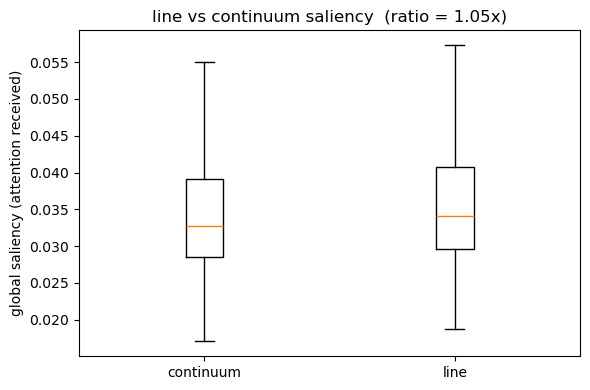

In [8]:
def token_is_line(R, b):
    """Bool per token: window [w-half, w+half] contains a catalogued line."""
    wave_t = R['wave_token'][b].numpy()
    z      = float(R['z'][b])
    dw     = np.median(np.diff(np.sort(wave_t))) if len(wave_t) > 1 else 0.01
    flags  = np.zeros(len(wave_t), dtype=bool)
    lo, hi = wave_t.min() - dw, wave_t.max() + dw
    for _, w in lines_obs(z, lo, hi).items():
        flags |= np.abs(wave_t - w) <= dw
    return flags

line_sal, cont_sal = [], []
n_batches = 0
for batch in dm.val_dataloader():
    Rb = attention_matrix(model, batch, block_k=BLOCK_K)
    B  = Rb['A'].shape[0]
    for b in range(B):
        tvm = Rb['tvm'][b].numpy()
        sal = np.nanmean(Rb['A_ext'][b].numpy(), axis=0)
        isl = token_is_line(Rb, b) & tvm
        isc = (~token_is_line(Rb, b)) & tvm
        line_sal.extend(sal[isl][np.isfinite(sal[isl])].tolist())
        cont_sal.extend(sal[isc][np.isfinite(sal[isc])].tolist())
    n_batches += 1
    if n_batches >= 4:   # cap cost
        break

line_sal = np.array(line_sal); cont_sal = np.array(cont_sal)
print(f"line tokens: {len(line_sal)}  mean={line_sal.mean():.4f}")
print(f"cont tokens: {len(cont_sal)}  mean={cont_sal.mean():.4f}")
print(f"ratio line/cont = {line_sal.mean() / cont_sal.mean():.2f}x")

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cont_sal, line_sal], tick_labels=['continuum', 'line'], showfliers=False)
ax.set_ylabel('global saliency (attention received)')
ax.set_title(f'line vs continuum saliency  (ratio = {line_sal.mean()/cont_sal.mean():.2f}x)')
plt.tight_layout(); plt.show()